# House Price Predictor from Scratch with NumPy

In this notebook I build a simple house price predictor from scratch using Python and NumPy.

The goal is not only to make predictions, but also to revisit the core concepts of machine learning step by step:

- Supervised Learning
- Linear Regression
- Prediction Function
- Cost Function
- Gradient Descent
- Multiple Features
- Vectorization
- Feature Scaling
- Polynomial Regression

This project helped me connect the theory behind machine learning with an actual implementation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Supervised Learning

This project is based on supervised learning.

In supervised learning, we train a model using:
- input features `X`
- target values `y`

In this case:

- `X` contains house-related information such as size, number of rooms, age, and floor
- `y` contains the house price

The model learns a relationship between the input variables and the target value.

In [2]:
# Synthetic housing dataset
m = 120

size = np.random.randint(50, 200, m).reshape(-1, 1)      # square meters
rooms = np.random.randint(1, 6, m).reshape(-1, 1)        # number of rooms
age = np.random.randint(0, 40, m).reshape(-1, 1)         # age of the house
floor = np.random.randint(0, 10, m).reshape(-1, 1)       # floor

# Target: house price
price = (
    3000 * size +
    12000 * rooms -
    800 * age +
    5000 * floor +
    np.random.randn(m, 1) * 15000
)

X = np.hstack([size, rooms, age, floor])
y = price


print("X shape:", X.shape)
print("y shape:", y.shape)

print("First 5 examples:")
print(X[:5])

print("First 5 target values:")
print(y[:5])

X shape: (120, 4)
y shape: (120, 1)
First 5 examples:
[[152   4  37   2]
 [142   5  39   0]
 [ 64   3  19   7]
 [156   3  34   2]
 [121   4  24   9]]
First 5 target values:
[[474997.13195693]
 [434669.8904392 ]
 [242910.40288528]
 [535609.77689131]
 [413625.01577105]]


## 2. Linear Regression

Linear regression is used to predict a continuous value.

In this project, the continuous value is the house price.

The model can be written as:

\[
f_{w,b}(x) = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
\]

Where:
- each feature contributes to the prediction
- each weight represents the importance of a feature
- `b` is the bias term

## 3. Prediction Function

The prediction function computes the estimated price for each house.

In [3]:
def predict(X, w, b):
    return X.dot(w) + b

## 4. Cost Function

The cost function measures how far the predictions are from the real values.

A lower cost means the model is making better predictions.

In linear regression, we often use the mean squared error formulation:

\[
J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2
\]

The goal of training is to minimize this function.

In [4]:
def compute_cost(X, y, w, b):
    m = len(y)
    predictions = predict(X, w, b)
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)

## 5. Gradient Descent

Gradient descent is the optimization algorithm used to update the parameters `w` and `b`.

At each iteration:
- we compute the current predictions
- we measure the error
- we compute the gradients
- we update the parameters in the direction that reduces the cost

This process is repeated until the model improves.

In [5]:
def gradient_descent(X, y, w, b, alpha, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        predictions = predict(X, w, b)

        dw = (1 / m) * X.T.dot(predictions - y)
        db = (1 / m) * np.sum(predictions - y)

        w = w - alpha * dw
        b = b - alpha * db

        cost_history.append(compute_cost(X, y, w, b))

    return w, b, cost_history

## 6. Multiple Features

Unlike simple linear regression, here the model uses multiple features.

Each house is described by more than one variable:
- size
- rooms
- age
- floor

This makes the model more realistic, because real-world predictions usually depend on multiple factors.

Learned weights:
[[923.81500942]
 [ 19.44197684]
 [148.93382394]
 [ 33.54678619]]
Learned bias:
6.793298395202599


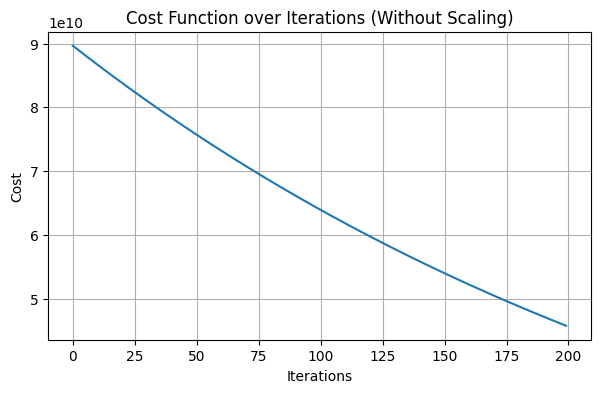

In [6]:
w = np.zeros((X.shape[1], 1))
b = 0

w, b, cost_history = gradient_descent(X, y, w, b, alpha=1e-7, iterations=200)

print("Learned weights:")
print(w)

print("Learned bias:")
print(b)

plt.figure(figsize=(7, 4))
plt.plot(cost_history)
plt.title("Cost Function over Iterations (Without Scaling)")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

## 7. Vectorization

This implementation uses NumPy vectorized operations instead of unnecessary Python loops.

For example:
- predictions are computed with a matrix multiplication
- gradients are computed with vector operations

This is important because vectorization makes the implementation:
- cleaner
- faster
- closer to how machine learning libraries work internally

## 8. Feature Scaling

Feature scaling is useful when the input variables have very different ranges.

In this dataset:
- size may be around 50 to 200
- rooms may be around 1 to 5
- age may be around 0 to 40
- floor may be around 0 to 10

Without scaling, gradient descent may converge slowly.

By normalizing the features, optimization becomes more stable and efficient.

In [7]:
def feature_scale(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_scaled = (X - mu) / sigma
    return X_scaled, mu, sigma

X_scaled, mu, sigma = feature_scale(X)
w_scaled = np.zeros((X_scaled.shape[1], 1))
b_scaled = 0

w_scaled, b_scaled, cost_history_scaled = gradient_descent(
    X_scaled, y, w_scaled, b_scaled, alpha=0.1, iterations=200
)

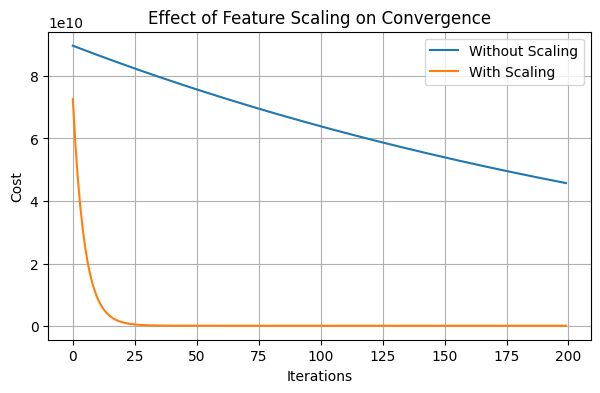

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(cost_history, label="Without Scaling")
plt.plot(cost_history_scaled, label="With Scaling")
plt.title("Effect of Feature Scaling on Convergence")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.grid(True)
plt.show()

## 9. Polynomial Regression

Polynomial regression extends the feature space by adding derived features such as squared terms.

For example:
- size
- size²

This allows the model to capture non-linear patterns while still remaining linear in the parameters.

In other words, the model becomes more flexible without changing the basic training process.

In [9]:
size_squared = size ** 2
X_poly = np.hstack([size, size_squared, rooms, age, floor])

X_poly_scaled, mu_poly, sigma_poly = feature_scale(X_poly)

w_poly = np.zeros((X_poly_scaled.shape[1], 1))
b_poly = 0

w_poly, b_poly, cost_history_poly = gradient_descent(
    X_poly_scaled, y, w_poly, b_poly, alpha=0.1, iterations=300
)

In [10]:
new_house = np.array([[120, 3, 10, 2]])  # size, rooms, age, floor
new_house_scaled = (new_house - mu) / sigma

predicted_price = predict(new_house_scaled, w_scaled, b_scaled)
print("Predicted house price:", predicted_price[0, 0])

Predicted house price: 397295.6024393161


## Final Takeaways

This project helped me revisit the core ideas behind machine learning by implementing them step by step.

Main concepts reviewed:
- supervised learning
- linear regression
- prediction function
- cost function
- gradient descent
- multiple features
- vectorization
- feature scaling
- polynomial regression

Building the model from scratch made the relationship between theory and implementation much clearer.